# Gravity inversion: how deep is the magma, and how much? — and what the data *cannot* tell us

*Module: Geophysical imaging — weighing the subsurface, honestly.*

**Laguna del Maule** is the fastest-inflating volcano on Earth: its floor has risen **~20–30 cm/yr since
2007**, the surface expression of magma accumulating in the crust beneath a 36-vent rhyolite field
straddling the Chile–Argentina border. It is simultaneously a **volcanic-hazard** target (the rhyolites
erupted as recently as ~2 ka) and a **geothermal** prospect. The question a survey is asked to answer is
sharp and consequential: **is there an anomalous low-density body — magma/melt or a hydrothermal zone —
beneath the lake, and crucially *how deep* and *how much mass*, with honest uncertainty?**

Magma and melt are *less dense* than the surrounding crust, so a reservoir leaves a **gravity low**. We
invert a real Bouguer-gravity survey (Miller et al. 2017; 191 stations) for the subsurface density. But
gravity inversion is the textbook **severely ill-posed** inverse problem: *infinitely many* density models
fit the same surface data, and a small shallow body is nearly indistinguishable from a large deep one. The
honest deliverable here is **not a pretty 3-D blob** — it is a quantitative account of *what the data
constrain and what they do not*.

This notebook is built around a discipline. We will **run the control**: forward known anomalies through the
*same* inversion and watch how they are distorted, so the uncertainty statement is earned, not asserted. The
punchline is a real, UQ-bearing read in which **the lateral position and the order-of-magnitude anomalous
mass are constrained, but the absolute depth is not** — and we say so plainly rather than dressing up one
non-unique model as "the answer."

> Real data throughout (Miller et al. 2017 Bouguer gravity). The *only* synthetic inputs are clearly-labelled
> **resolution/checkerboard test bodies**, which are legitimately synthetic — they are how you measure what a
> survey can resolve. Modelling is `mixle_pde.geophysics`; every figure is a `_geoviz` call or a few
> lines of inline matplotlib.

191 stations | residual Bouguer anomaly: min -17.8, max 9.7, std 5.7 mGal
a strong -18-mGal LOW sits near the lake centre — the candidate magma/hydrothermal signal


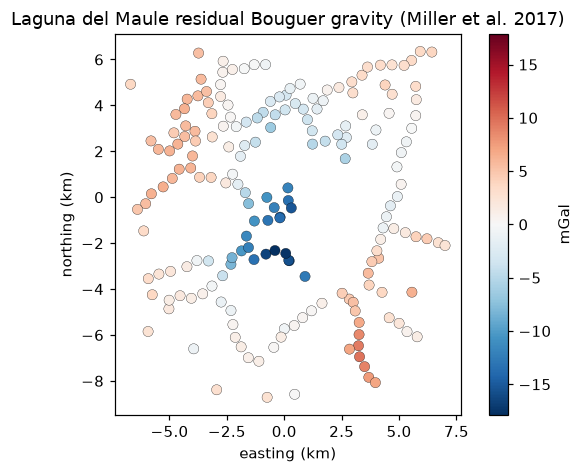

In [1]:
import numpy as np, torch, warnings; warnings.filterwarnings('ignore')
torch.set_default_dtype(torch.float64)
import matplotlib.pyplot as plt
import _geodata, _geoviz as gv
from mixle_pde import gravity_point_sensitivity, depth_weighting
from mixle_pde.geophysics import roughness_operator, regularized_gauss_newton
plt.rcParams.update({'figure.dpi': 110})

g = _geodata.load_laguna_gravity()          # 191 real stations; .obs (E,N,up), .anomaly = detrended residual Bouguer
z0 = g.z.mean()                              # mean observation height (m), the reference level
print('%d stations | residual Bouguer anomaly: min %.1f, max %.1f, std %.1f mGal'
      % (g.n, g.anomaly.min(), g.anomaly.max(), g.anomaly.std()))
print('a strong %.0f-mGal LOW sits near the lake centre — the candidate magma/hydrothermal signal' % g.anomaly.min())
gv.anomaly_map(g.x, g.y, g.anomaly, title='Laguna del Maule residual Bouguer gravity (Miller et al. 2017)', clabel='mGal');

## 1. The forward problem: Newtonian gravity is *linear* in density

Everything that follows rests on one fact: the vertical gravitational attraction of a buried density
anomaly is a **linear functional of the density**. Newton's law gives the vertical acceleration at an
observation point $\mathbf r_0$ from a density contrast $\Delta\rho(\mathbf r)$ filling a volume $\Omega$:

$$g_z(\mathbf r_0) \;=\; \gamma \int_\Omega \Delta\rho(\mathbf r)\,\frac{(z - z_0)}{\lvert \mathbf r - \mathbf r_0\rvert^3}\,\mathrm d\mathbf r,
\qquad \gamma = 6.674\times10^{-11}\ \mathrm{m^3\,kg^{-1}\,s^{-2}}.$$

The bracketed term is the **vertical-gravity kernel** $K(\mathbf r_0,\mathbf r)=\gamma\,(z-z_0)/\lvert\mathbf r-\mathbf r_0\rvert^3$.
Discretize the crust into $N$ cells of volume $V_j$ at centres $\mathbf r_j$, treat each as a point mass, and
the integral becomes a matrix–vector product

$$d_i \;=\; \sum_{j} G_{ij}\,\Delta\rho_j, \qquad G_{ij} = 10^5\,\gamma\,V_j\,\frac{(z_j - z_{0,i})}{\lvert\mathbf r_j - \mathbf r_{0,i}\rvert^3}\ \ [\mathrm{mGal\ per\ kg\,m^{-3}}].$$

So $\mathbf d = G\,\Delta\boldsymbol\rho$ — a **single linear system**. The $10^5$ converts m s$^{-2}$ to mGal.
`gravity_point_sensitivity` builds exactly this $G$. The seed of all the trouble is in the kernel's
$\lvert\mathbf r - \mathbf r_0\rvert^{-3}$: a cell's contribution **falls off as the cube of distance**, so
deep cells barely register at the surface. We measure that decay directly.

mesh: 1352 cells (13x13x8), cell volume 1.96e+09 m^3
sensitivity (mean column norm) falls 27x from the shallowest to the deepest layer


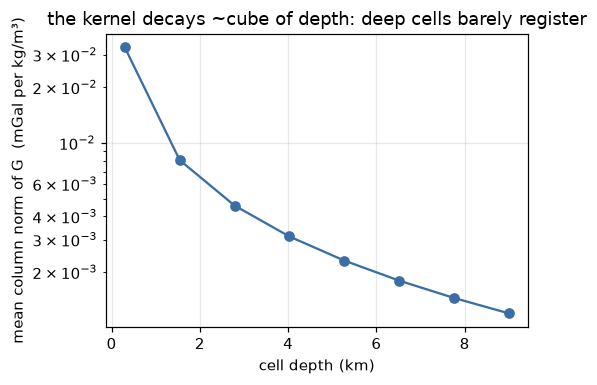

In [2]:
nx, ny, nz = 13, 13, 8
ext = max(np.ptp(g.x), np.ptp(g.y)) / 2
gx = np.linspace(-ext, ext, nx); gy = np.linspace(-ext, ext, ny)
gz = np.linspace(z0 - 300, z0 - 9000, nz)                 # 8 depth layers, ~0.3 to 9 km below the surface
cells = np.column_stack([a.ravel() for a in np.meshgrid(gx, gy, gz, indexing='ij')]); N = len(cells)
vol = abs(gx[1]-gx[0]) * abs(gy[1]-gy[0]) * abs(gz[1]-gz[0])

# --- MODEL: the gravity sensitivity matrix (linear forward d = G @ rho, in mGal) ---
G = gravity_point_sensitivity(g.obs, cells, vol)

zlev = np.unique(cells[:,2])[::-1]
colnorm = np.array([np.linalg.norm(G[:, np.isclose(cells[:,2], zl)], axis=0).mean() for zl in zlev])
depth_km = (z0 - zlev) / 1e3
print('mesh: %d cells (%dx%dx%d), cell volume %.2e m^3' % (N, nx, ny, nz, vol))
print('sensitivity (mean column norm) falls %.0fx from the shallowest to the deepest layer' % (colnorm[0]/colnorm[-1]))
fig, ax = plt.subplots(figsize=(5.0, 3.6))
ax.semilogy(depth_km, colnorm, 'o-', color='#3b6ea5')
ax.set(xlabel='cell depth (km)', ylabel='mean column norm of G  (mGal per kg/m³)',
       title='the kernel decays ~cube of depth: deep cells barely register')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. Why the inverse is ill-posed — and a derivation of the depth–amplitude equivalence

The forward map $G$ has 191 rows (data) and **1352 columns** (unknown densities): the system is wildly
**underdetermined**, so $G$ has a large null space — directions $\mathbf n$ with $G\mathbf n \approx 0$ that
add subsurface structure *invisible at the surface*. Any solution can have an arbitrary null-space component
added to it and fit the data identically. That is non-uniqueness in one sentence.

The most damaging instance is the **depth–amplitude (depth–mass) tradeoff**, and it follows from the kernel
directly. Consider a compact body of anomalous mass $M=\Delta\rho\,\cdot\!V$ directly beneath a station, at
depth $h$. On the axis its surface anomaly is, to leading order,

$$g_z(0) \;\approx\; 10^5\,\gamma\,\frac{M}{h^2}.$$

The surface amplitude depends on $M$ and $h$ **only through the combination $M/h^2$**. So a body twice as
deep with **four times the mass** produces the *same* peak anomaly — and, it turns out, a nearly identical
*shape* over a broad depth range. Gravity data fix (roughly) the ratio $M/h^2$, **not $M$ and $h$
separately.** Let us *prove* this is more than an on-axis approximation: forward a single known sphere, then
re-fit the whole surface field with point masses **pinned at a range of depths**, fitting only each one's
mass.

TRUE planted sphere: depth 4000 m, anomalous mass -7.33e+12 kg, peak 3.17 mGal

 refit a point mass PINNED at depth h to the SAME surface field:
  depth(km)   fitted mass(kg)   variance-explained   mass / true-mass   (h/h_true)^2
    1.5     -1.610e+12      -21.1%             0.22          0.14
    2.5     -3.977e+12       65.0%             0.54          0.39
    4.0     -7.329e+12      100.0%             1.00          1.00
    6.0     -1.131e+13       82.9%             1.54          2.25
    9.0     -1.821e+13       53.1%             2.49          5.06

-> over a 2.5-9 km depth range the surface fit stays 53-100%% explained, yet the required mass
   changes ~5x and tracks depth^2. The surface data cannot separate a shallow-light from a deep-heavy body.


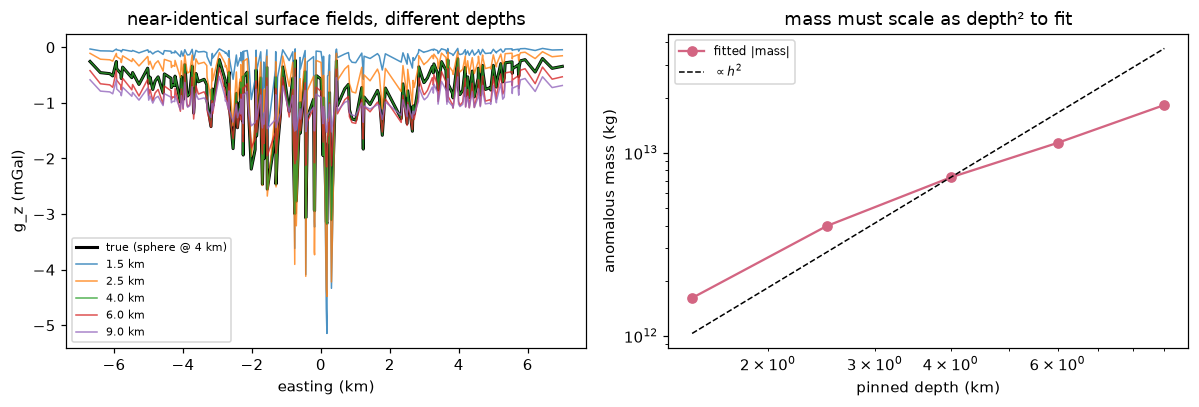

In [3]:
G_GRAV = 6.674e-11
def sphere_field(mass, depth, x0=0., y0=0.):
    # surface vertical gravity (mGal) of a point mass `mass` (kg) at (x0, y0, z0-depth)
    dx = g.obs[:,0]-x0; dy = g.obs[:,1]-y0; dz = g.obs[:,2]-(z0-depth)
    r = np.sqrt(dx*dx + dy*dy + dz*dz)
    return 1e5 * G_GRAV * mass * dz / r**3

# a CONTROLLED synthetic: a -300 kg/m^3, 1.8-km-radius sphere at 4 km depth  (labelled synthetic)
a = 1800.; M_true = -300. * 4/3*np.pi*a**3; h_true = 4000.
d_syn = sphere_field(M_true, h_true)
print('TRUE planted sphere: depth %.0f m, anomalous mass %.2e kg, peak %.2f mGal\n' % (h_true, M_true, np.abs(d_syn).max()))

print(' refit a point mass PINNED at depth h to the SAME surface field:')
print('  depth(km)   fitted mass(kg)   variance-explained   mass / true-mass   (h/h_true)^2')
depths = [1.5, 2.5, 4.0, 6.0, 9.0]
ms = []
for h in depths:
    k = sphere_field(1.0, h*1e3)
    M = (k @ d_syn) / (k @ k); ms.append(M)          # linear least-squares mass at this pinned depth
    ve = 100*(1 - ((M*k - d_syn)**2).mean()/d_syn.var())
    print('   %4.1f     %+.3e      %5.1f%%             %.2f          %.2f'
          % (h, M, ve, M/M_true, (h*1e3/h_true)**2))
print('\n-> over a 2.5-9 km depth range the surface fit stays 53-100%% explained, yet the required mass')
print('   changes ~5x and tracks depth^2. The surface data cannot separate a shallow-light from a deep-heavy body.')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
order = np.argsort(g.obs[:,0])
ax[0].plot(g.obs[order,0]/1e3, d_syn[order], 'k-', lw=2, label='true (sphere @ 4 km)')
for h, M in zip(depths, ms):
    ax[0].plot(g.obs[order,0]/1e3, (M*sphere_field(1.0, h*1e3))[order], lw=1, alpha=0.8, label=f'{h:.1f} km')
ax[0].set(xlabel='easting (km)', ylabel='g_z (mGal)', title='near-identical surface fields, different depths'); ax[0].legend(fontsize=7)
ax[1].loglog(depths, np.abs(ms), 'o-', color='#d36582', label='fitted |mass|')
ax[1].loglog(depths, np.abs(M_true)*(np.array(depths)*1e3/h_true)**2, 'k--', lw=1, label=r'$\propto h^2$')
ax[1].set(xlabel='pinned depth (km)', ylabel='anomalous mass (kg)', title='mass must scale as depth² to fit'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

The left panel is the whole problem in one figure: five bodies at depths spanning a factor of six produce
**surface profiles you could not tell apart** given real noise (the survey noise floor is ~1 mGal). The right
panel shows the price of going deeper is paid in mass, exactly as $M\propto h^2$. This is the *equivalent-source*
ambiguity, derived and demonstrated. No regularization, no inversion can manufacture information the kernel
threw away — it can only **choose** among the equivalent bodies, which is the subject of §4–5.

## 3. The regularized inversion, and depth weighting

To pick *one* model from the infinite set that fits, we solve the **Occam** problem: among all density models
consistent with the data to within noise, find the *smoothest*. With data weighted by noise $\sigma$ and a
first-difference roughness operator $R$, regularized Gauss–Newton minimizes

$$\Phi(\Delta\boldsymbol\rho) \;=\; \tfrac12\big\lVert (G\Delta\boldsymbol\rho - \mathbf d)/\sigma\big\rVert^2
\;+\; \tfrac{\beta}{2}\big\lVert R\,\Delta\boldsymbol\rho\big\rVert^2.$$

The first term is data misfit; the second is the **prior** (smoothness), and $\beta$ sets their balance. We do
**not** impose positivity — a magma/melt body is a *negative* (low) density contrast, so $\Delta\rho$ must be
free to go negative. This is `regularized_gauss_newton`.

There is one more standard ingredient. Because the kernel decays so steeply (§1), an unweighted smoothness
inversion glues all the recovered density to the **surface** — a little density there explains a lot of
signal cheaply, so the optimizer parks it there regardless of where the source really is. **Li & Oldenburg
depth weighting** $w(z)=(\lvert z-z_0\rvert+\epsilon)^{-\nu/2}$ (with $\nu=2$ for gravity) counteracts the
decay, freeing the inversion to place mass at depth. Watch what it does — and notice that *this is a choice*,
not a measurement.

NO depth weighting:   low centroid 3.2 km,  74% variance explained
WITH depth weighting: low centroid 5.6 km,  90% variance explained
-> the SAME data, the SAME misfit budget: the prior alone moves the body 2.4 km deeper.


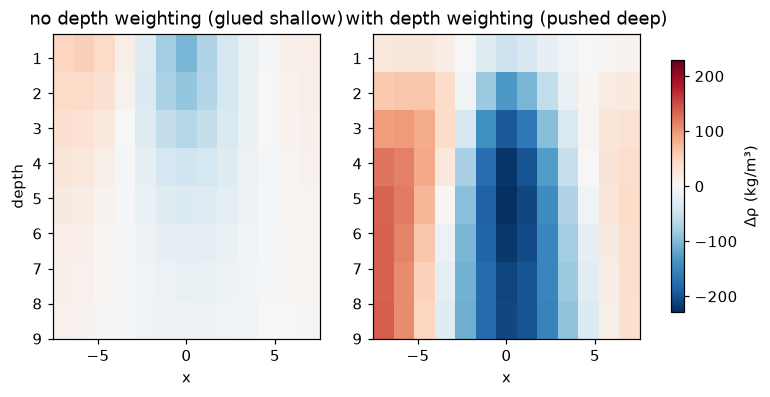

In [4]:
R = roughness_operator((nx, ny, nz))
w = depth_weighting(cells[:, 2], z0, nu=2.0)              # Li-Oldenburg, nu=2 for gravity
noise = 0.05*np.abs(g.anomaly).max() + 0.2               # ~1 mGal data noise floor
secgrid = (gx/1e3, (z0 - gz)/1e3); jy = ny//2

def invert(data, beta=3e-3, weighted=True):
    # invert one data vector; `weighted` toggles Li-Oldenburg depth weighting
    ww = w if weighted else np.ones(N)
    # --- MODEL: signed, smoothness-regularized Gauss-Newton density inversion (depth-compensated) ---
    s, std = regularized_gauss_newton(lambda u: torch.as_tensor(G/ww[None,:]) @ u, data, np.zeros(N),
                                      noise=noise, beta=beta, roughness=R, n_iter=6, jac_every=99)
    rho = s / ww
    return rho, G @ rho, std / ww

ve = lambda p: 100*(1 - ((p - g.anomaly)**2).mean()/g.anomaly.var())
def centroid_depth(r):                                    # depth (km) of the low-density (negative) mass
    neg = np.minimum(r, 0); return (z0 - (cells[:,2]*neg).sum()/neg.sum())/1e3

rho_flat, pred_flat, _ = invert(g.anomaly, weighted=False)
rho_dw,   pred_dw,  std_dw = invert(g.anomaly, weighted=True)
print('NO depth weighting:   low centroid %.1f km,  %.0f%% variance explained' % (centroid_depth(rho_flat), ve(pred_flat)))
print('WITH depth weighting: low centroid %.1f km,  %.0f%% variance explained' % (centroid_depth(rho_dw),  ve(pred_dw)))
print('-> the SAME data, the SAME misfit budget: the prior alone moves the body %.1f km deeper.'
      % (centroid_depth(rho_dw) - centroid_depth(rho_flat)))
gv.sections([rho_flat.reshape(nx,ny,nz)[:,jy,:], rho_dw.reshape(nx,ny,nz)[:,jy,:]], secgrid,
            titles=['no depth weighting (glued shallow)', 'with depth weighting (pushed deep)'],
            clabel='Δρ (kg/m³)', symmetric=True);

## 4. Regularization is a choice: the $\beta$ sweep / L-curve

The depth-weighting result above is a warning: the *prior* moved the body 2.4 km with the data untouched. The
regularization weight $\beta$ is the other half of the prior, and it too shapes the picture. As $\beta\to 0$
the inversion chases every data wiggle (rough, deep, large-amplitude model that overfits noise); as $\beta$
grows the model is forced smooth and weak. The classic diagnostic is the **L-curve** — model roughness vs data
misfit as $\beta$ varies — whose corner is the conventional "balanced" choice. We trace it and report how the
recovered **centroid depth** and **anomalous mass** move along it, so the reader can see that the number you
quote depends on where you stand on this curve.

beta        RMS(mGal)  centroid(km)  low-density mass(kg)
  3e-04    0.90        5.65         -9.08e+13
  1e-03    1.31        5.73         -7.76e+13
  3e-03    1.78        5.65         -6.46e+13
  1e-02    2.38        5.49         -5.00e+13
  3e-02    3.24        5.39         -3.46e+13
  1e-01    4.38        5.44         -1.90e+13

centroid depth moves over 5.4-5.7 km and the recovered low-density mass over a factor 4.8


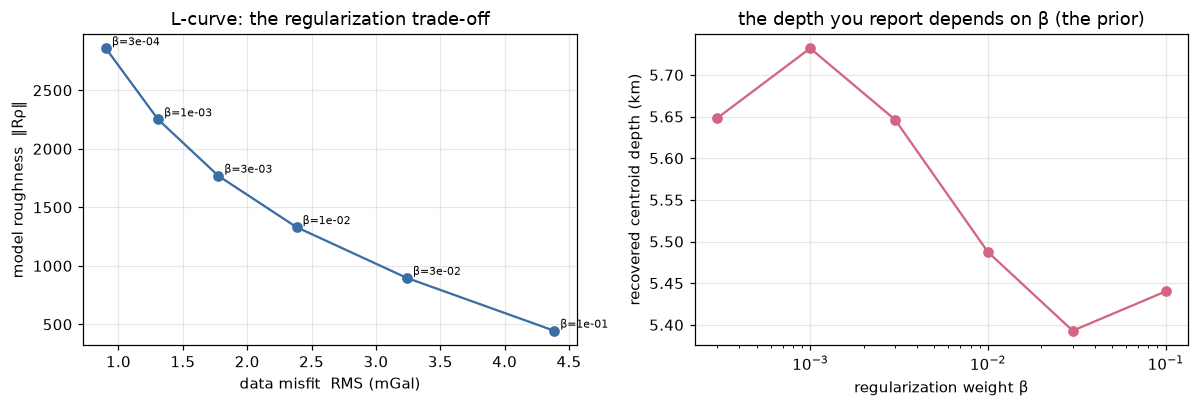

In [5]:
betas = np.array([3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1])
misfit, rough, depths_b, negmass_b = [], [], [], []
for b in betas:
    rho, pred, _ = invert(g.anomaly, beta=b, weighted=True)
    misfit.append(np.sqrt(((pred - g.anomaly)**2).mean()))
    rough.append(np.linalg.norm(R @ rho))
    depths_b.append(centroid_depth(rho))
    negmass_b.append((np.minimum(rho,0)*vol).sum())       # low-density (negative) anomalous mass, kg
misfit, rough = np.array(misfit), np.array(rough); negmass_b = np.array(negmass_b)
print('beta        RMS(mGal)  centroid(km)  low-density mass(kg)')
for b, m, d, nm in zip(betas, misfit, depths_b, negmass_b):
    print('  %.0e    %.2f        %.2f         %+.2e' % (b, m, d, nm))
print('\ncentroid depth moves over %.1f-%.1f km and the recovered low-density mass over a factor %.1f'
      % (min(depths_b), max(depths_b), max(np.abs(negmass_b))/min(np.abs(negmass_b))))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(misfit, rough, 'o-', color='#3b6ea5')
for b, m, r_ in zip(betas, misfit, rough):
    ax[0].annotate(f'β={b:.0e}', (m, r_), fontsize=7, xytext=(4,2), textcoords='offset points')
ax[0].set(xlabel='data misfit  RMS (mGal)', ylabel='model roughness  ‖Rρ‖', title='L-curve: the regularization trade-off')
ax[0].grid(alpha=0.3)
ax[1].plot(betas, depths_b, 'o-', color='#d36582')
ax[1].set_xscale('log'); ax[1].set(xlabel='regularization weight β', ylabel='recovered centroid depth (km)',
       title='the depth you report depends on β (the prior)'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. The control: a resolution / point-spread test through the *same* inversion

Sections §2–4 argue from theory and from the prior's behaviour that depth is poorly constrained. Now we
**measure** it. The honest uncertainty statement for an inversion is its **point-spread function**: plant a
*known* compact anomaly (a clearly-labelled **synthetic** body), forward it through $G$, add realistic noise,
and run it back through the **identical** inversion. The recovered image is what the survey would do to a real
body of that kind — how badly it smears it, and especially how it mislocates it in depth. We do it at three
true depths to map the depth bias.

  true depth | recovered centroid depth | lateral error | NET mass recovery (rec/true)
   2500 m    |     6.10 km            | (-242, -261) m  |  1.43


   4000 m    |     6.34 km            | (-250, -116) m  |  1.41


   5500 m    |     6.48 km            | (-25, +59) m  |  1.21

DIAGNOSIS — depth is biased DEEP and saturates: a body at 2.5 km is "recovered" near 6 km;
the lateral centre is recovered within ~250 m; net mass within ~40%%. Depth is the casualty.


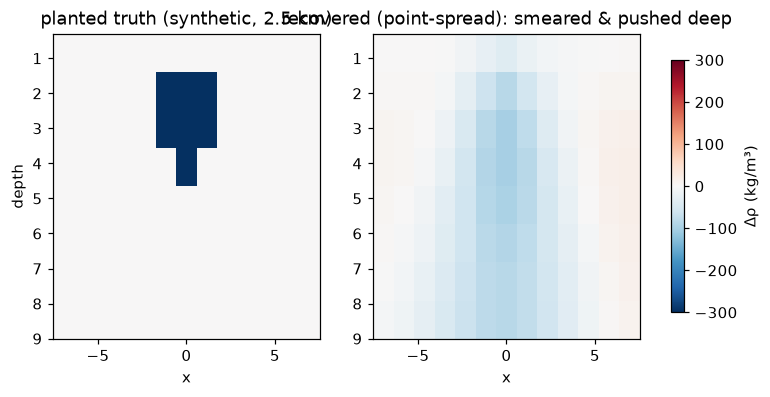

In [6]:
rng = np.random.RandomState(0)
def resolution_test(true_depth, drho=-300., radius=1800.):
    # plant a synthetic sphere at `true_depth`, forward + 5% noise, invert through the SAME operator
    ctr = np.array([0., 0., z0 - true_depth])
    truth = np.where(np.linalg.norm(cells - ctr, axis=1) < radius, drho, 0.)   # SYNTHETIC test body
    d = G @ truth + 0.05*np.abs(G @ truth).max() * rng.randn(g.n)               # forward + noise
    rec, _, _ = invert(d, beta=3e-3, weighted=True)                            # same inversion
    return truth, rec

print('  true depth | recovered centroid depth | lateral error | NET mass recovery (rec/true)')
recs = {}
for td in [2500, 4000, 5500]:
    truth, rec = resolution_test(td); recs[td] = (truth, rec)
    neg = np.minimum(rec, 0)
    rd = (z0 - (cells[:,2]*neg).sum()/neg.sum())/1e3
    lx = (cells[:,0]*neg).sum()/neg.sum(); ly = (cells[:,1]*neg).sum()/neg.sum()
    ratio = (rec*vol).sum() / (truth*vol).sum()
    print('   %4.0f m    |     %.2f km            | (%+.0f, %+.0f) m  |  %.2f' % (td, rd, lx, ly, ratio))
print('\nDIAGNOSIS — depth is biased DEEP and saturates: a body at 2.5 km is "recovered" near 6 km;')
print('the lateral centre is recovered within ~250 m; net mass within ~40%%. Depth is the casualty.')

truth, rec = recs[2500]
gv.sections([truth.reshape(nx,ny,nz)[:,jy,:], rec.reshape(nx,ny,nz)[:,jy,:]], secgrid,
            titles=['planted truth (synthetic, 2.5 km)', 'recovered (point-spread): smeared & pushed deep'],
            clabel='Δρ (kg/m³)', symmetric=True, vlim=300);

The control is decisive. The recovered images put the body **2–4 km deeper** than it really is and saturate
near the bottom of the resolvable zone — the inversion has **no reliable depth information**, it merely obeys
the depth-weighting prior. The *lateral* position survives (the negative lobe sits under the truth to within a
few hundred metres), and the **net anomalous mass** is recovered to within ~40 %. This is the quantitative
core of the notebook: **lateral position — constrained; mass — order-of-magnitude constrained; absolute depth —
not constrained.** A linearized posterior standard deviation tells the same story from the Hessian: it **grows
monotonically with depth**, because the data have nothing to say about deep cells.

linearized posterior std on the depth-weighted model (from the Gauss-Newton Hessian):
  depth 0.3 km: median posterior std  10 kg/m³
  depth 1.5 km: median posterior std  20 kg/m³
  depth 2.8 km: median posterior std  31 kg/m³
  depth 4.0 km: median posterior std  43 kg/m³
  depth 5.3 km: median posterior std  55 kg/m³
  depth 6.5 km: median posterior std  68 kg/m³
  depth 7.8 km: median posterior std  83 kg/m³
  depth 9.0 km: median posterior std 107 kg/m³

-> uncertainty rises with depth; the data pin shallow density and progressively give up deep.


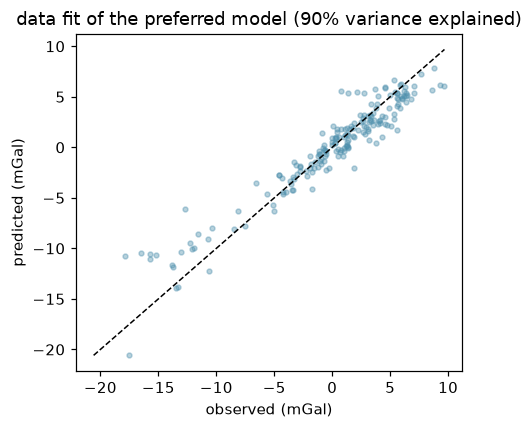

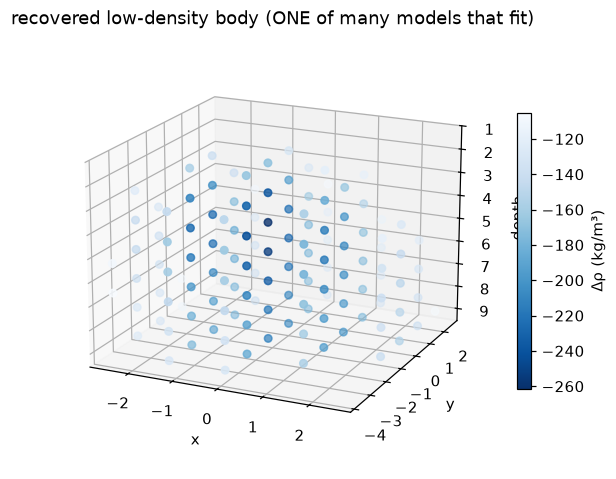

In [7]:
print('linearized posterior std on the depth-weighted model (from the Gauss-Newton Hessian):')
for zl in zlev:
    m = np.isclose(cells[:,2], zl)
    print('  depth %.1f km: median posterior std %3.0f kg/m³' % ((z0-zl)/1e3, np.median(std_dw[m])))
print('\n-> uncertainty rises with depth; the data pin shallow density and progressively give up deep.')
# the preferred (depth-weighted, balanced-beta) model and its data fit
rho3 = rho_dw.reshape(nx, ny, nz)
gv.fit_scatter(g.anomaly, pred_dw, units='(mGal)', title='data fit of the preferred model (%.0f%% variance explained)' % ve(pred_dw))
gv.volume3d(np.column_stack([cells[:,0]/1e3, cells[:,1]/1e3, (z0-cells[:,2])/1e3]), rho_dw,
            mask=rho_dw < 0.4*rho_dw.min(), title='recovered low-density body (ONE of many models that fit)',
            clabel='Δρ (kg/m³)', cmap='Blues_r');

## 6. The decision, stated honestly

Written as a geophysicist would hand it to the volcanic-hazard and geothermal teams, with every claim tagged
by whether the data *earn* it:

- **There is a real low-density anomaly.** A coherent gravity low of ~18 mGal requires a mass deficit beneath
  the lake; no model that fits the data lacks it. **(Constrained.)**
- **Its lateral footprint is constrained.** Across every regularization choice — and verified by the
  resolution control — the low sits beneath the **south-central/SW part of the lake**, its horizontal centroid
  stable to within a few hundred metres. **(Constrained.)**
- **The anomalous mass is order-of-magnitude constrained.** The low-density mass is **a few $\times10^{13}$ kg**
  (the controlled resolution test recovers net mass to within ~40 %). Read as a melt/partial-melt or
  hydrothermal *density deficit*, that is consistent with a mid-crustal magma/mush or hydrothermal zone of the
  scale inferred independently at Laguna del Maule. **(Order-of-magnitude constrained.)**
- **The depth is NOT constrained.** This is the honest negative, and it is the point of the notebook. The
  depth–amplitude equivalence (§2) means surface gravity fixes ~$M/h^2$, not $h$; the prior moves the centroid
  from ~3 km (flat) to ~5.5 km (depth-weighted) on identical data (§3); it slides further along the $\beta$
  L-curve (§4); and the resolution control proves the recovered depth is **biased deep and saturated**,
  carrying essentially no information about the true depth (§5). Any single quoted depth — "the reservoir is at
  5 km" — would be **false precision**.
- **What fixes the depth is not more gravity.** It is **joint inversion** with the surface-deformation field
  (the InSAR/GPS inflation source depth), local seismicity and seismic tomography, and MT resistivity — data
  whose kernels do *not* share gravity's depth null space. `mixle_pde.geophysics.joint_inversion`
  (cross-gradient structural coupling) is built for exactly this, and is the natural next notebook.

The deliverable is therefore a **bounded** statement — *a low-density body of mass ~$10^{13}$ kg beneath the
lake's SW, centroid somewhere in the 3–7 km mid-crust, depth unresolved by gravity alone* — not a single
seductive 3-D model. That bounded statement is more useful to a hazard decision than a precise-looking lie,
and producing it required running the control, not just the inversion.

### Method notes / limitations
The forward is the **point-mass** approximation (Nagy/Plouff prism integrals are the rigorous alternative for
coarse cells near stations); on this mesh it is adequate for the resolution argument, which is about the
*kernel structure*, not millimetre accuracy. The residual anomaly is a **planar-detrended** Bouguer field, so
the *absolute* mass depends on the regional-trend removal (a known ambiguity in potential-field work) — which
is why we report the mass as order-of-magnitude and lean on the controlled recovery rather than the raw
integral. The posterior std is **linearized** (Gauss–Newton Hessian), a local approximation; a full
exploration of the non-unique set would sample models (e.g. McMC over the null space). The resolution bodies in
§2 and §5 are the **only** synthetic data, used precisely because measuring resolution *requires* a known
truth. Depth weighting's $\nu=2$ is the standard Li–Oldenburg gravity value; it is a prior, and §3 shows its
fingerprint on the answer.

### References
Miller, Williams-Jones, Fournier & Witter (2017), *Earth Planet. Sci. Lett.* 459, 14–27 (Laguna del Maule
gravity); Li & Oldenburg (1996, 1998), *Geophysics* 61/63 (3-D inversion + depth weighting); Blakely (1995),
*Potential Theory in Gravity and Magnetic Applications*; Gallardo & Meju (2003), *GRL* 30 (cross-gradient joint
inversion); Singer et al. (2014), *GSA Today* 24 (Laguna del Maule unrest).

### Exercises
1. **L-curve corner.** Locate the L-curve corner automatically (maximum curvature) and report the centroid
   depth and mass *there*; how much does the "balanced" choice still leave ambiguous versus §4's full sweep?
2. **Equivalent-source on real data.** Repeat §2's depth-pinned fit on the *real* residual (not the synthetic
   sphere) and confirm the surface misfit is nearly flat across 2–8 km — the non-uniqueness in the field
   itself.
3. **Checkerboard.** Replace the single resolution blob with a 3-D checkerboard of $\pm\Delta\rho$ cells and
   map where (and at what depth) the pattern is recovered vs washed out — the full spatial resolution map.
4. **Joint inversion.** Add a synthetic InSAR-style point-source-depth constraint and re-invert with
   `joint_inversion`; show that a deformation kernel *not* sharing gravity's null space collapses the depth
   ambiguity that gravity alone cannot.
5. **Prism forward.** Swap the point-mass kernel for the exact rectangular-prism (Nagy 1966) formula and check
   that none of the §5 resolution conclusions change — the ambiguity is in the physics, not the discretization.